In [ ]:
!pip install h3 geopandas shapely -q

In [ ]:
# Import libraries
import geopandas as gpd
from shapely.geometry import Polygon
import h3

In [ ]:
# 2. Load country boundaries

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

# Select Oman
oman = world[world["NAME"] == "Oman"]

In [ ]:
# 3. Extract Oman geometry

oman_geom = oman.geometry.values[0]

# Convert to GeoJSON format for H3
oman_geojson = oman_geom.__geo_interface__


In [ ]:
# 4. Generate H3 hex grid

resolution = 6   # Change to 7 for finer grid

hex_ids = h3.geo_to_cells(oman_geojson, res=resolution)

print("Total hexes generated:", len(hex_ids))

Total hexes generated: 10374


In [ ]:
# 5. Convert H3 cells → polygons

hex_polygons = []
hex_list = []

for h in hex_ids:
    coords = h3.cell_to_boundary(h)

    # Convert (lat, lon) → (lon, lat)
    coords = [(lng, lat) for lat, lng in coords]

    polygon = Polygon(coords)

    hex_polygons.append(polygon)
    hex_list.append(h)

hex_gdf = gpd.GeoDataFrame(
    {"hex_id": hex_list, "geometry": hex_polygons},
    crs="EPSG:4326"
)


In [ ]:
# 6. Ensure same CRS

hex_gdf = hex_gdf.to_crs(oman.crs)


# 7. Clip to Oman boundary

oman_hex = gpd.clip(hex_gdf, oman)

print("Hexes after clipping:", len(oman_hex))


Hexes after clipping: 10374


<Axes: >

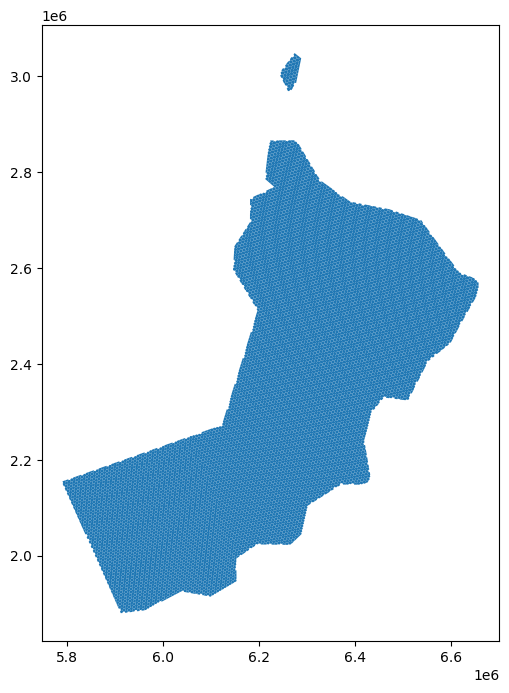

In [ ]:
# 8. Plot result

oman_hex.to_crs("EPSG:3857").plot(figsize=(8, 8))


In [ ]:
# 9. Compute centroids

oman_hex_proj = oman_hex.to_crs("EPSG:3857")

centroids = oman_hex_proj.centroid

centroids = gpd.GeoSeries(centroids, crs="EPSG:3857").to_crs("EPSG:4326")

oman_hex["lat"] = centroids.y
oman_hex["lon"] = centroids.x

In [ ]:
# 10. Save shapefile

oman_hex.to_file(
    "oman_h3_res6.shp",
    driver="ESRI Shapefile"
)

print("Shapefile saved successfully!")

Shapefile saved successfully!
